# BioListen VN — ESC-50 Preprocessing Pipeline (`human_head`) [On-Demand Extraction]

Notebook này thực hiện tiền xử lý cho bộ dữ liệu **ESC-50** phục vụ nhánh phân loại mối đe dọa con người (`human_head`).

### Chiến lược tối ưu dung lượng ổ cứng (On-Demand Extraction):
Nhằm tránh việc Google Colab bị đầy bộ nhớ khi giải nén toàn bộ các file audio raw, notebook này sử dụng phương pháp **giải nén theo yêu cầu (On-Demand Extraction)**:
- Lập chỉ mục toàn bộ các file trong file zip raw từ Google Drive.
- Đọc metadata `esc50.csv` trực tiếp từ file zip vào bộ nhớ RAM.
- Duyệt qua từng file âm thanh, giải nén **duy nhất** file đó ra bộ nhớ tạm của Colab, thực hiện các bước tiền xử lý chuyển thành tensor `.pt`, sau đó **xóa ngay lập tức** file raw trước khi chuyển sang mẫu tiếp theo.
- Cuối cùng, nén toàn bộ các file `.pt` kết quả thành file `.zip` duy nhất trên Google Drive.

### Quy trình xử lý âm học:
1. Chuẩn hóa về **Mono**, resample về **32,000 Hz**.
2. Cắt/Đệm (Slice/Pad) độ dài cố định đúng **5.0 giây** (160,000 samples).
3. Trích xuất **Log-Mel Spectrogram** ($f_{min} = 50$ Hz, $f_{max} = 15,000$ Hz, $n_{mels} = 128$).
4. Tính toán các đặc trưng **Delta** và **Delta-Delta** để tạo thành 3 kênh màu (R = Mel, G = Delta, B = Delta-Delta).
5. Resize song tuyến (bilinear) về kích thước ảnh vuông `(3, 224, 224)`.
6. Lưu trữ các tensor dưới dạng tệp PyTorch `.pt` và xuất tệp metadata CSV tương ứng.

## 1. Kết nối Google Drive & Thiết lập Đường dẫn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import shutil
from tqdm import tqdm

# Cấu hình đường dẫn đầu vào và đầu ra trên Google Drive
drive_raw_zip = '/content/drive/MyDrive/Datasets/BioListenVN/raw_zips/ESC-50-master.zip'
drive_processed_dir = '/content/drive/MyDrive/Datasets/BioListenVN/processed'

# Đường dẫn làm việc trên cục bộ
local_processed_dir = '/content/esc50_processed'
os.makedirs(drive_processed_dir, exist_ok=True)
os.makedirs(local_processed_dir, exist_ok=True)

if os.path.exists(drive_raw_zip):
    print(f"Tìm thấy raw zip file tại: {drive_raw_zip}")
else:
    print(f"LỖI: Không tìm thấy file tại {drive_raw_zip}. Vui lòng upload dữ liệu lên Drive.")

Mounted at /content/drive
Tìm thấy raw zip file tại: /content/drive/MyDrive/Datasets/BioListenVN/raw_zips/ESC-50-master.zip


## 2. Import các Thư viện cần thiết

In [2]:
import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
import glob

print("PyTorch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)

PyTorch version: 2.11.0+cpu
Torchaudio version: 2.11.0+cpu


## 3. Lập chỉ mục Zip file và Đọc Metadata trực tiếp vào bộ nhớ RAM

In [3]:
if os.path.exists(drive_raw_zip):
    with zipfile.ZipFile(drive_raw_zip, 'r') as z:
        # Tìm file esc50.csv
        csv_files = [f for f in z.namelist() if f.endswith('esc50.csv')]
        if len(csv_files) > 0:
            with z.open(csv_files[0]) as f:
                df = pd.read_csv(f)
            print(f"Đã đọc file metadata trực tiếp từ zip: {csv_files[0]} (Số dòng: {len(df)})")

            # Lập chỉ mục đường dẫn tất cả file audio trong zip
            print("Đang lập chỉ mục danh sách file audio trong zip...")
            all_files = z.namelist()
            audio_in_zip = [p for p in all_files if p.endswith('.wav')]
            file_to_zip_path = {os.path.basename(p): p for p in audio_in_zip}
            print(f"Đã lập chỉ mục xong {len(audio_in_zip)} file WAV.")
        else:
            print("LỖI: Không tìm thấy file metadata esc50.csv trong file zip!")

Đã đọc file metadata trực tiếp từ zip: ESC-50-master/meta/esc50.csv (Số dòng: 2000)
Đang lập chỉ mục danh sách file audio trong zip...
Đã lập chỉ mục xong 2000 file WAV.


## 4. Cấu hình Tham số và Xây dựng Lớp Preprocessor

In [4]:
# Cấu hình thống nhất theo tài liệu EDA_pipeline.md
AUDIO_CONFIG = {
    "sample_rate": 32000,
    "duration_sec": 5,
    "n_samples": 32000 * 5,
    "n_fft": 2048,
    "hop_length": 512,
    "n_mels": 128,
    "fmin_human": 50,
    "fmax": 15000,
}

class ESC50AudioPreprocessor:
    def __init__(self, config=AUDIO_CONFIG):
        self.target_sr = config["sample_rate"]
        self.target_samples = config["n_samples"]
        self.n_fft = config["n_fft"]
        self.hop_length = config["hop_length"]
        self.n_mels = config["n_mels"]
        self.fmin = config["fmin_human"]
        self.fmax = config["fmax"]

        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=self.target_sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            f_min=self.fmin,
            f_max=self.fmax
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def preprocess(self, file_path):
        # 1. Load file âm thanh
        waveform, sr = torchaudio.load(file_path)

        # 2. Chuẩn hóa về Mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # 3. Resample về 32,000 Hz
        if sr != self.target_sr:
            resampler = T.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform = resampler(waveform)

        # 4. Temporal Alignment (Cắt/Pad đúng 5s)
        num_samples = waveform.shape[1]
        if num_samples > self.target_samples:
            waveform = waveform[:, :self.target_samples]
        elif num_samples < self.target_samples:
            pad_len = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_len))

        # 5. Trích xuất Mel-spectrogram & Chuyển sang dB scale
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec)

        # 6. Chuẩn hóa Min-Max về dải [0, 1] cho Spectrogram gốc
        min_val = mel_spec_db.min()
        max_val = mel_spec_db.max()
        if max_val - min_val > 1e-9:
            mel_spec_norm = (mel_spec_db - min_val) / (max_val - min_val)
        else:
            mel_spec_norm = torch.zeros_like(mel_spec_db)

        # 7. Resize song tuyến (Bilinear) về ảnh vuông (224, 224)
        mel_spec_unsqueezed = mel_spec_norm.unsqueeze(0)
        mel_spec_resized = torch.nn.functional.interpolate(
            mel_spec_unsqueezed,
            size=(224, 224),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        # 8. Tính Delta & Delta-Delta
        delta = torchaudio.functional.compute_deltas(mel_spec_resized)
        delta2 = torchaudio.functional.compute_deltas(delta)

        # Hàm chuẩn hóa từng kênh về dải [0, 1]
        def norm_tensor(t):
            mn, mx = t.min(), t.max()
            if mx - mn > 1e-9:
                return (t - mn) / (mx - mn)
            return torch.zeros_like(t)

        mel_spec_resized_norm = norm_tensor(mel_spec_resized)
        delta_norm = norm_tensor(delta)
        delta2_norm = norm_tensor(delta2)

        # Ghép thành 3 kênh màu RGB
        mel_rgb = torch.cat([mel_spec_resized_norm, delta_norm, delta2_norm], dim=0)

        return waveform, mel_spec_db, mel_rgb

## 5. Chạy Thử nghiệm và Trực quan hóa Đặc trưng 3 kênh

File test: /content/temp_test.wav | Lớp: FROG


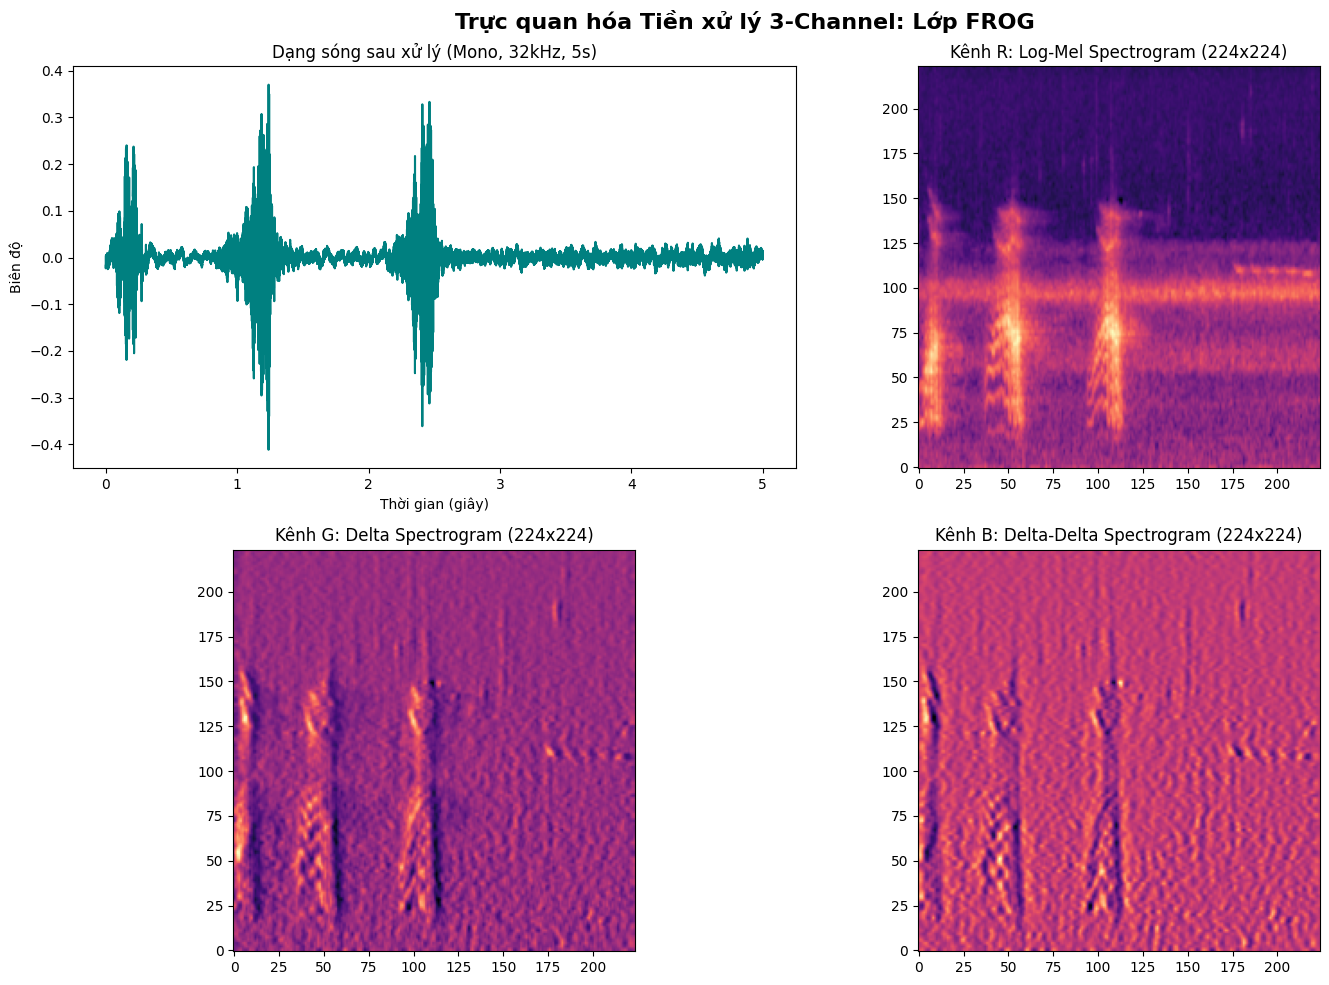

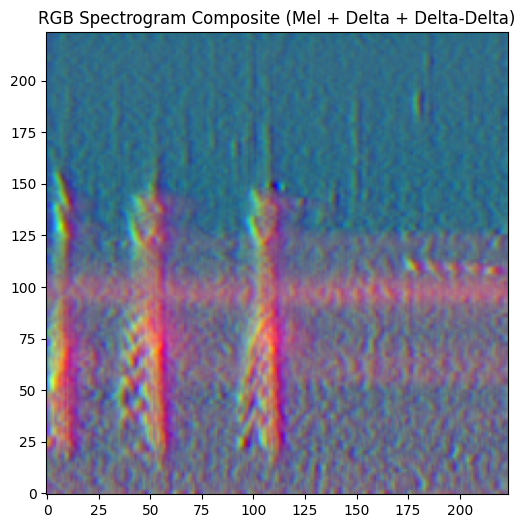

In [5]:
if 'df' in locals() and 'file_to_zip_path' in locals():
    # Lấy thử 1 file ngẫu nhiên để visual
    sample_row = df.sample(1).iloc[0]
    fname = sample_row['filename']

    if fname in file_to_zip_path:
        zip_member = file_to_zip_path[fname]
        temp_test_file = '/content/temp_test.wav'

        # Giải nén tạm đúng 1 file này
        with zipfile.ZipFile(drive_raw_zip, 'r') as z:
            with z.open(zip_member) as source, open(temp_test_file, 'wb') as target:
                shutil.copyfileobj(source, target)

        print(f"File test: {temp_test_file} | Lớp: {sample_row['category'].upper()}")

        preprocessor = ESC50AudioPreprocessor()
        waveform, spec_db, mel_rgb = preprocessor.preprocess(temp_test_file)

        # Xóa file tạm ngay
        if os.path.exists(temp_test_file):
            os.remove(temp_test_file)

        # Trực quan hóa
        fig, axs = plt.subplots(2, 2, figsize=(15, 10))

        # 1. Waveform
        axs[0, 0].plot(np.linspace(0, 5, len(waveform[0])), waveform[0].numpy(), color='teal')
        axs[0, 0].set_title("Dạng sóng sau xử lý (Mono, 32kHz, 5s)")
        axs[0, 0].set_xlabel("Thời gian (giây)")
        axs[0, 0].set_ylabel("Biên độ")

        # 2. R-channel (Mel-Spectrogram)
        axs[0, 1].imshow(mel_rgb[0].numpy(), cmap='magma', origin='lower')
        axs[0, 1].set_title("Kênh R: Log-Mel Spectrogram (224x224)")
        axs[0, 1].grid(False)

        # 3. G-channel (Delta)
        axs[1, 0].imshow(mel_rgb[1].numpy(), cmap='magma', origin='lower')
        axs[1, 0].set_title("Kênh G: Delta Spectrogram (224x224)")
        axs[1, 0].grid(False)

        # 4. B-channel (Delta-Delta)
        axs[1, 1].imshow(mel_rgb[2].numpy(), cmap='magma', origin='lower')
        axs[1, 1].set_title("Kênh B: Delta-Delta Spectrogram (224x224)")
        axs[1, 1].grid(False)

        plt.suptitle(f"Trực quan hóa Tiền xử lý 3-Channel: Lớp {sample_row['category'].upper()}", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Hiển thị ảnh RGB gộp
        plt.figure(figsize=(6, 6))
        rgb_img = mel_rgb.permute(1, 2, 0).numpy()
        plt.imshow(rgb_img, origin='lower')
        plt.title("RGB Spectrogram Composite (Mel + Delta + Delta-Delta)")
        plt.grid(False)
        plt.show()
    else:
        print("Không tìm thấy file trong zip mapping.")

## 6. Chạy Tiền xử lý Toàn bộ Dữ liệu với On-Demand Extraction

In [6]:
if 'df' in locals() and 'file_to_zip_path' in locals():
    processed_records = []
    preprocessor = ESC50AudioPreprocessor()

    print("Bắt đầu tiền xử lý toàn bộ ESC-50 sử dụng On-Demand Extraction...")

    temp_process_file = '/content/temp_process.wav'

    with zipfile.ZipFile(drive_raw_zip, 'r') as z:
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing ESC-50"):
            fname = row['filename']

            if fname in file_to_zip_path:
                zip_member = file_to_zip_path[fname]

                # 1. Giải nén tạm đúng 1 file này
                with z.open(zip_member) as source, open(temp_process_file, 'wb') as target:
                    shutil.copyfileobj(source, target)

                # 2. Thực hiện tiền xử lý
                _, _, mel_rgb = preprocessor.preprocess(temp_process_file)

                # 3. Xóa file tạm ngay lập tức
                if os.path.exists(temp_process_file):
                    os.remove(temp_process_file)

                # 4. Lưu tensor PyTorch cục bộ
                out_name = fname.replace('.wav', '.pt')
                dest_path = os.path.join(local_processed_dir, out_name)
                torch.save(mel_rgb, dest_path)

                # Ghi nhận log metadata dynamically (tránh KeyError đối với các cột tùy biến như 'src', 'esc10', v.v.)
                record = {
                    'filename': fname,
                    'processed_pt_filename': out_name
                }
                for col in df.columns:
                    if col != 'filename':
                        record[col] = row[col]
                processed_records.append(record)

    processed_df = pd.DataFrame(processed_records)
    print(f"Đã tiền xử lý thành công {len(processed_df)} / {len(df)} mẫu.")

Bắt đầu tiền xử lý toàn bộ ESC-50 sử dụng On-Demand Extraction...


Preprocessing ESC-50: 100%|██████████| 2000/2000 [01:26<00:00, 23.23it/s]

Đã tiền xử lý thành công 2000 / 2000 mẫu.


## 7. Lưu Metadata mới & Đồng bộ hóa lên Google Drive

In [7]:
if 'processed_df' in locals() and len(processed_df) > 0:
    # 1. Lưu file csv metadata mới trực tiếp lên Google Drive
    meta_dest = os.path.join(drive_processed_dir, 'esc50_processed_metadata.csv')
    processed_df.to_csv(meta_dest, index=False)
    print(f"Đã lưu file metadata mới tại: {meta_dest}")

    # 2. Nén các file .pt kết quả thành file zip trực tiếp trên Drive
    zip_dest_name = os.path.join(drive_processed_dir, 'esc50_processed')
    print(f"Đang nén các tệp processed .pt vào file zip tại Drive...")
    shutil.make_archive(zip_dest_name, 'zip', local_processed_dir)
    print(f"Đã nén và đồng bộ thành công lên Google Drive: {zip_dest_name}.zip")

Đã lưu file metadata mới tại: /content/drive/MyDrive/Datasets/BioListenVN/processed/esc50_processed_metadata.csv
Đang nén các tệp processed .pt vào file zip tại Drive...
Đã nén và đồng bộ thành công lên Google Drive: /content/drive/MyDrive/Datasets/BioListenVN/processed/esc50_processed.zip


## 8. Dọn dẹp Thư mục cục bộ

In [8]:
print("Đang dọn dẹp các thư mục tạm cục bộ...")
if os.path.exists(local_processed_dir):
    shutil.rmtree(local_processed_dir)
print("Đã dọn dẹp sạch sẽ ổ cứng cục bộ!")

Đang dọn dẹp các thư mục tạm cục bộ...
Đã dọn dẹp sạch sẽ ổ cứng cục bộ!
